# Batch effect correction / integration

In [2]:
# —— RUN THIS BEFORE ANYTHING ELSE ———————————————————————————————
import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive; drive.mount('/content/drive')
    %run /content/drive/MyDrive/immerge_workshop/codes/notebooks/setup_notebook.py

In [3]:
import warnings
warnings.filterwarnings("ignore")

import gc
import glob as glob_mod
import os
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
# import scvi
import seaborn as sns
from anndata.experimental import concat_on_disk

sc.settings.verbosity = 3
sc.set_figure_params(dpi=100, frameon=False, figsize=(6, 5))
ad.settings.allow_write_nullable_strings = True

In [ ]:
INPUT_DIR = "results/temp/session2_part2/"
OUT_DIR = "results/temp/session2_part3/"

os.makedirs(OUT_DIR, exist_ok=True)

In [5]:
adata = sc.read(INPUT_DIR + "adata_s2part2.h5ad")

In [6]:
adata

AnnData object with n_obs × n_vars = 61724 × 30926
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors', 'pct_genes_expressed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts

# 1. Harmony

> *Harmony works on the PCA embedding coordinates of the cells and runs an
> iterative algorithm to adjust for dataset/donor-specific effects.*

Input: a PCA. Output: a **corrected PCA** in `obsm['X_pca_harmony']`. Everything
downstream (.e.g neighbourhood graph, UMAP, clustering) has to be recomputed on it.

In [7]:
import harmonypy

ho = harmonypy.run_harmony(adata.obsm["X_pca"].astype(np.float64), adata.obs, "Donor_id")

Z = np.asarray(ho.Z_corr)
adata.obsm["X_pca_harmony"] = Z if Z.shape[0] == adata.n_obs else Z.T
print(adata.obsm["X_pca_harmony"].shape)   

2026-09-15 16:36:07,229 - harmonypy - INFO - Running Harmony
2026-09-15 16:36:07,231 - harmonypy - INFO -   Parameters:
2026-09-15 16:36:07,232 - harmonypy - INFO -     max_iter_harmony: 10
2026-09-15 16:36:07,233 - harmonypy - INFO -     max_iter_kmeans: 4
2026-09-15 16:36:07,235 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-09-15 16:36:07,235 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-09-15 16:36:07,236 - harmonypy - INFO -     nclust: 100
2026-09-15 16:36:07,238 - harmonypy - INFO -     block_size: 0.05
2026-09-15 16:36:07,239 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-09-15 16:36:07,240 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2.]
2026-09-15 16:36:07,240 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-09-15 16:36:07,243 - harmonypy - INFO -     verbose: True
2026-09-15 16:36:07,243 - harmonypy - INFO -     random_state: 0
2026-09-15 16:36:07,244 - harmonypy - INFO -   Data: 50 PCs × 61724 cells
2026-09-15 16:36:07,244 - harmon

(61724, 50)


> ### ✏️ Exercise 1 — rerun the downstream steps
>
> Recompute the neighbourhood graph, UMAP and Leiden **on the Harmony embedding**,
> without overwriting the uncorrected results.
>
> Hints: `sc.pp.neighbors(..., use_rep="X_pca_harmony", key_added="harmony")`,

<details>
<summary><i>Show solution</i></summary>

```python
K = 15
sc.pp.neighbors(adata, n_neighbors=K, use_rep="X_pca_harmony", key_added="harmony")

sc.tl.umap(adata, neighbors_key="harmony", key_added="X_umap_harmony")

sc.tl.leiden(adata, resolution=0.3, key_added="leiden_harmony",
             neighbors_key="harmony", flavor="igraph", n_iterations=2,
             directed=False)
```

</details>

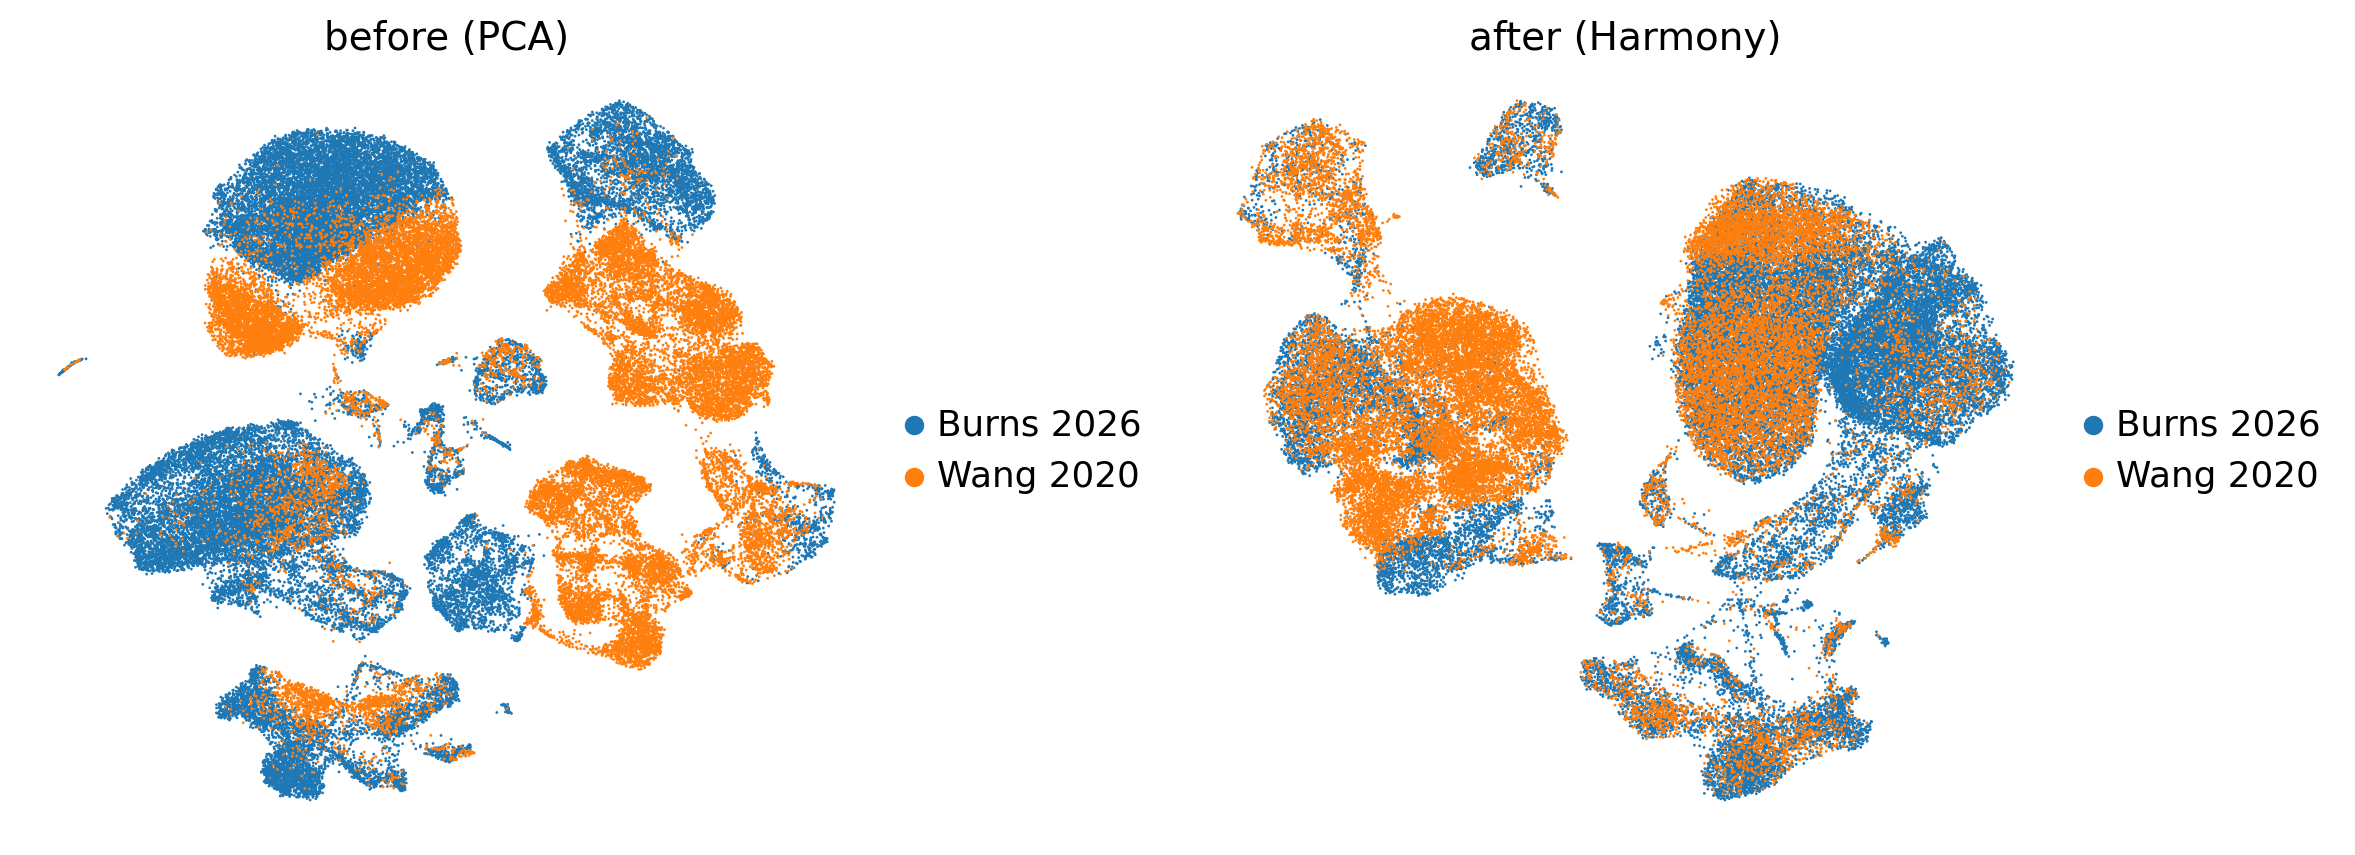

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sc.pl.umap(adata, color="Dataset", ax=axes[0], show=False,
           title="before (PCA)", size=4)
sc.pl.embedding(adata, basis="X_umap_harmony", color="Dataset", ax=axes[1],
                show=False, title="after (Harmony)", size=4)
plt.tight_layout(); plt.show()

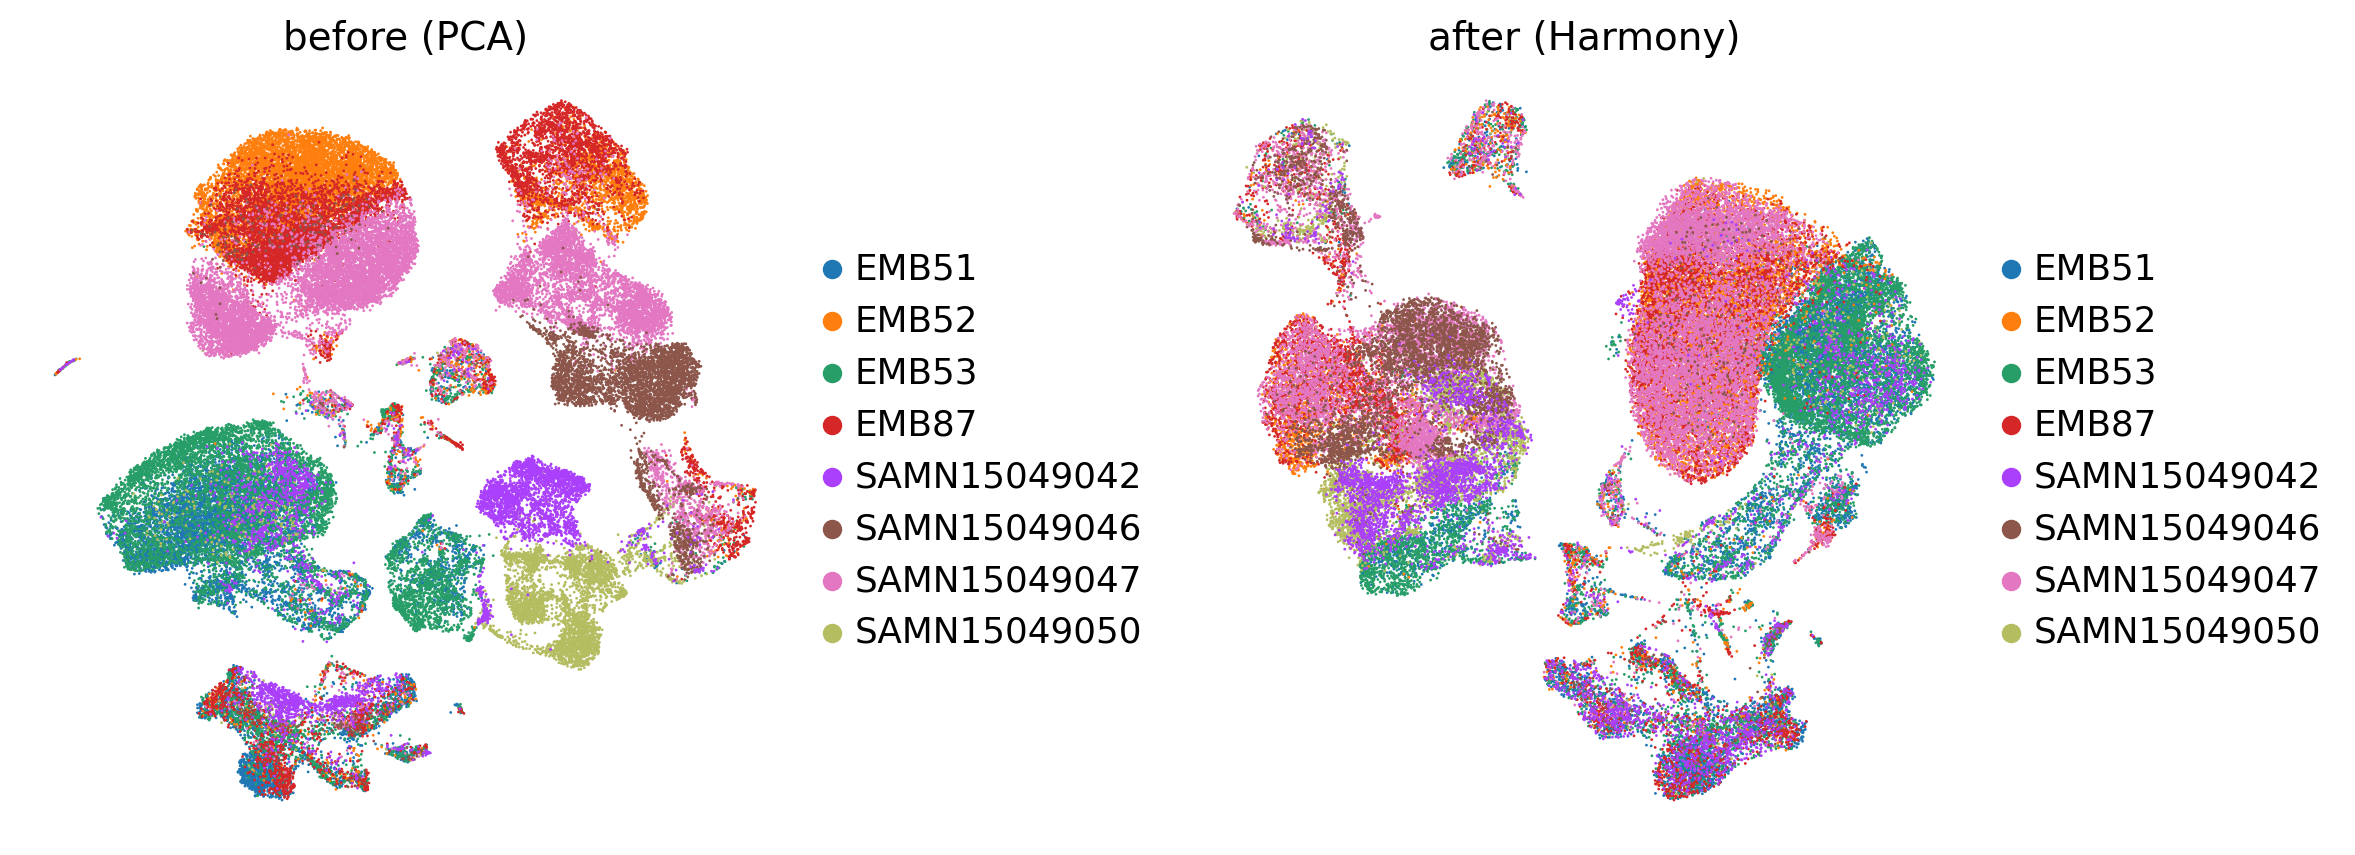

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sc.pl.umap(adata, color="Donor_id", ax=axes[0], show=False,
           title="before (PCA)", size=4)
sc.pl.embedding(adata, basis="X_umap_harmony", color="Donor_id", ax=axes[1],
                show=False, title="after (Harmony)", size=4)
plt.tight_layout(); plt.show()

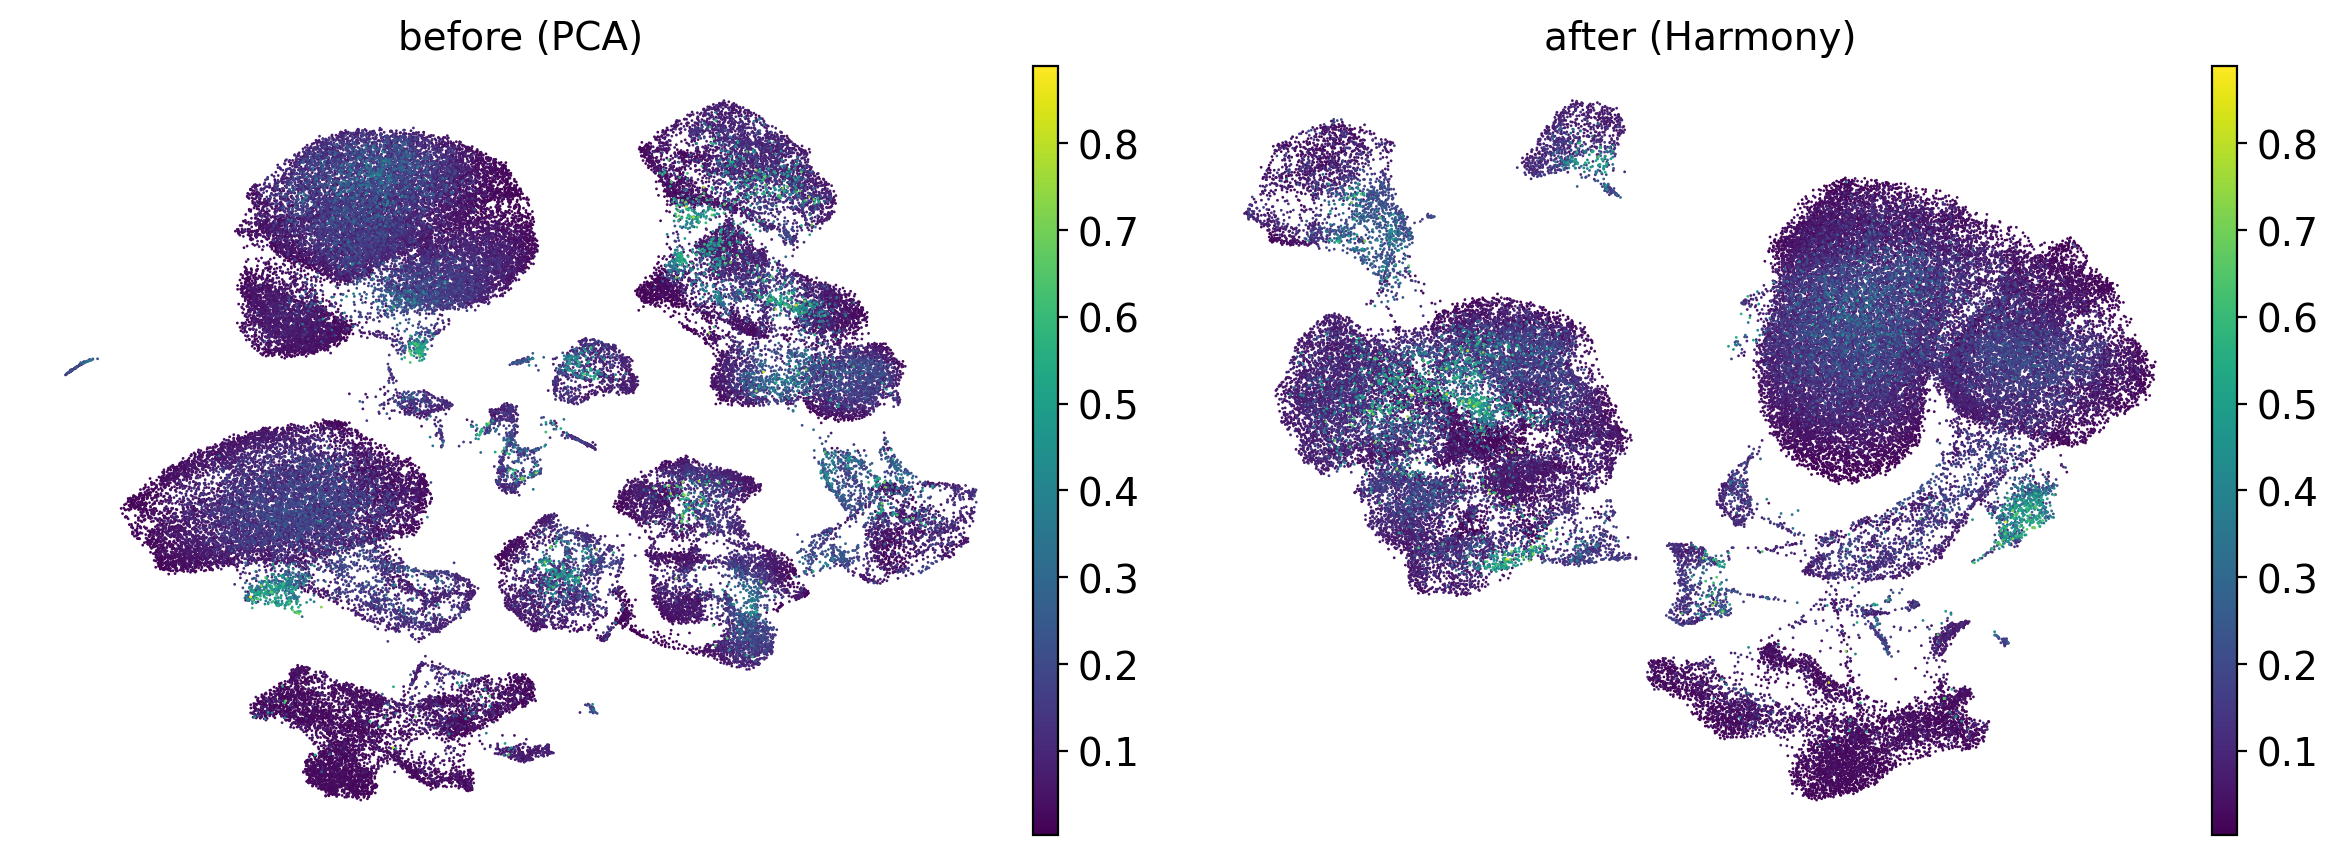

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sc.pl.umap(adata, color="doublet_scores", ax=axes[0], show=False,
           title="before (PCA)", size=4)
sc.pl.embedding(adata, basis="X_umap_harmony", color="doublet_scores", ax=axes[1],
                show=False, title="after (Harmony)", size=4)
plt.tight_layout(); plt.show()

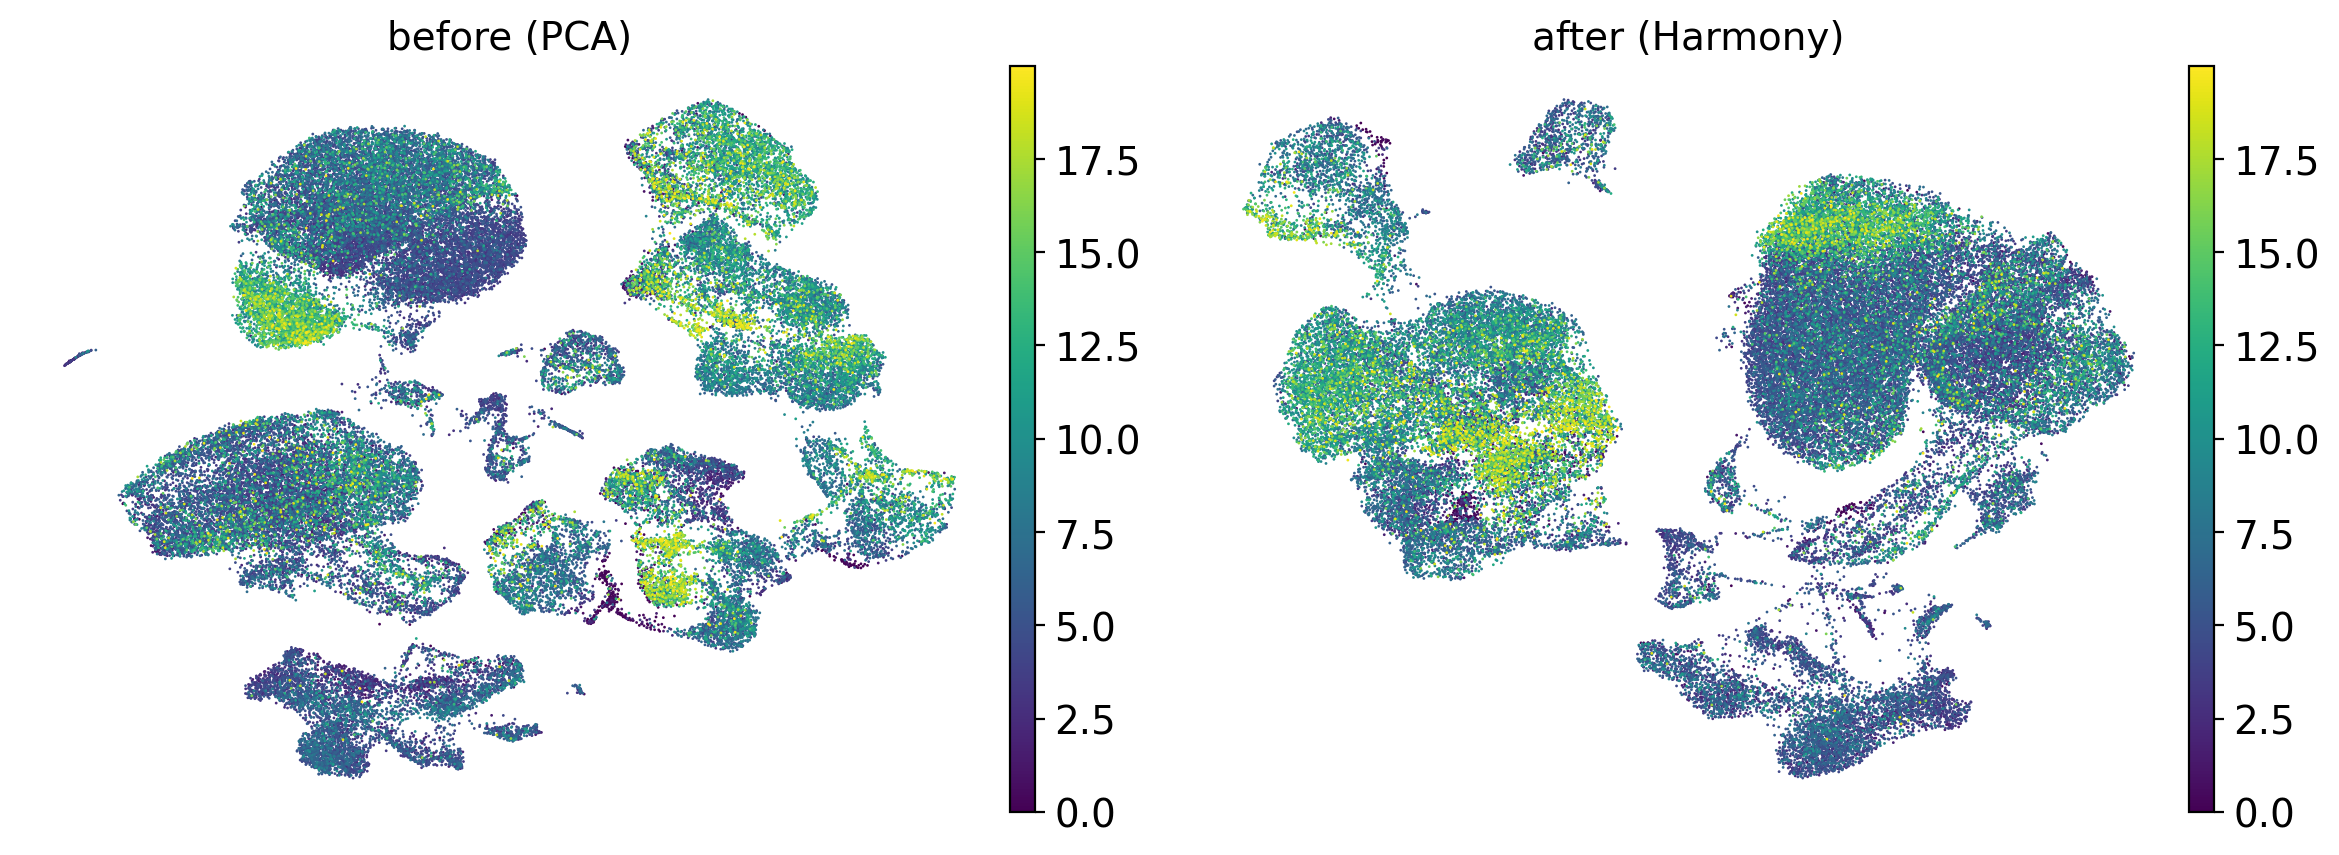

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sc.pl.umap(adata, color="pct_counts_mt", ax=axes[0], show=False,
           title="before (PCA)", size=4)
sc.pl.embedding(adata, basis="X_umap_harmony", color="pct_counts_mt", ax=axes[1],
                show=False, title="after (Harmony)", size=4)
plt.tight_layout(); plt.show()

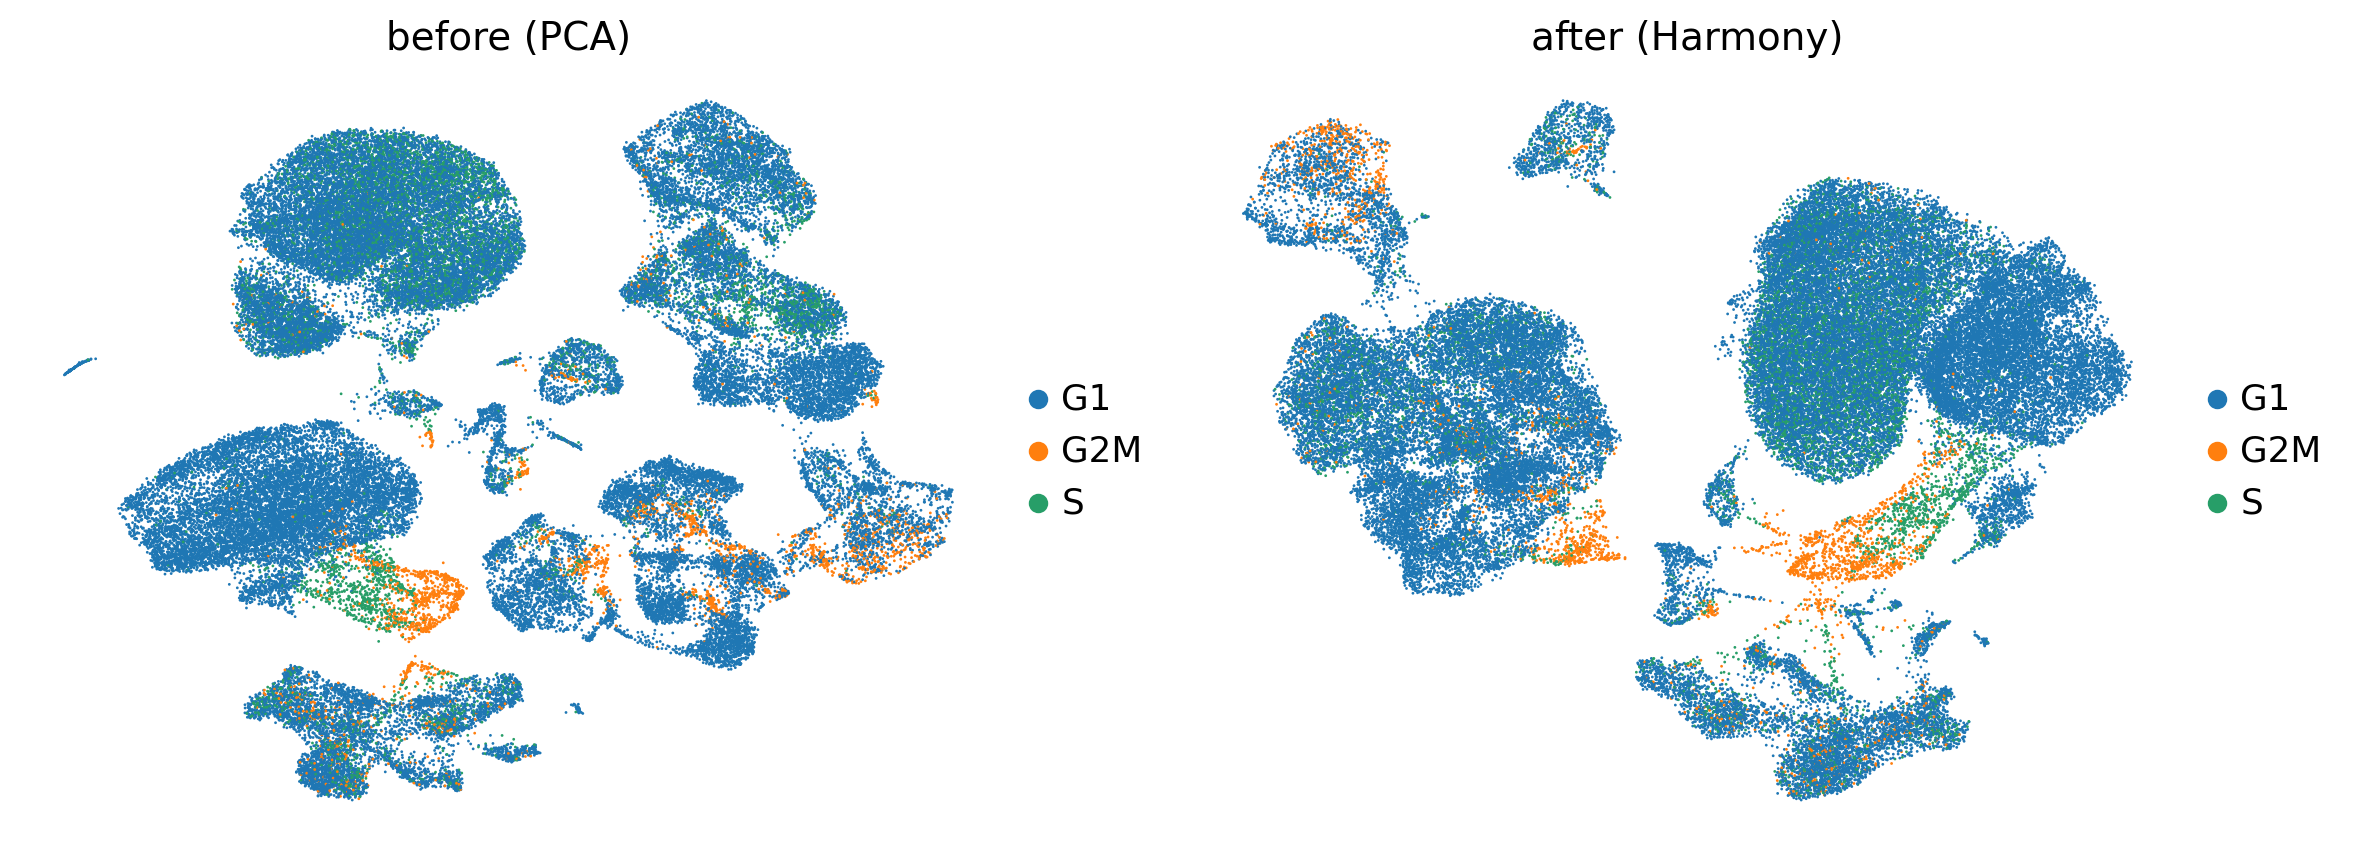

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sc.pl.umap(adata, color="phase", ax=axes[0], show=False,
           title="before (PCA)", size=4)
sc.pl.embedding(adata, basis="X_umap_harmony", color="phase", ax=axes[1],
                show=False, title="after (Harmony)", size=4)
plt.tight_layout(); plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sc.pl.umap(adata, color="my_annotation", ax=axes[0], show=False,
           title="before (PCA)", size=4)
sc.pl.embedding(adata, basis="X_umap_harmony", color="my_annotation", ax=axes[1],
                show=False, title="after (Harmony)", size=4)
plt.tight_layout(); plt.show()

In [ ]:
adata.write(OUT_DIR + "adata_s2part2_harmony.h5ad")

# 2. scVI

> *End-to-end method that models raw gene expression counts directly.*

Unlike Harmony, scVI **replaces** the PCA rather than correcting it, and it needs
**raw counts** — which is why we kept `adata.layers["counts"]`. It also requires a GPU to run in a sensible time. 

In [ ]:
import scvi

sub = adata[:, adata.var["highly_variable"]].copy()
sub.X = sub.layers["counts"].copy()
print(sub.shape)

In [ ]:
batch_key = "Donor_id"
scvi.model.SCVI.setup_anndata(sub, layer="counts", batch_key=batch_key)
model = scvi.model.SCVI(sub, n_latent=30, n_layers=2)
model.train(max_epochs=100, early_stopping=True)
adata.obsm["X_scVI"] = model.get_latent_representation()

In [ ]:
sc.pp.neighbors(adata, n_neighbors=K, use_rep="X_scVI", key_added="scvi")
sc.tl.umap(adata, neighbors_key="scvi", key_added="X_umap_scvi")

sc.tl.leiden(adata, resolution=0.3, key_added="leiden_scvi",
             neighbors_key="scvi", flavor="igraph", n_iterations=2,
             directed=False)

sc.pl.embedding(adata, basis="X_umap_scvi",
                    color=["Dataset", "Donor_id", "doublet_scores", "phase", "pct_counts_mt", "leiden_scvi", "my_annotation"], ncols=2, size=4)

In [ ]:
adata.write(OUT_DIR + "adata_s2part2_scvi.h5ad")